<a href="https://colab.research.google.com/github/Mayaamohamed/unemployment-Data-analysis-after-covid-19/blob/unemployement/unemployment_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as p

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 10.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5


In [ ]:
import os

print(os.listdir(path))


['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']


In [ ]:

df = p.read_csv(os.path.join(path, "Unemployment in India.csv"))
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
# explore data
df.shape #no of rows , no of columns
df.columns # name of columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
# statitics of data
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
# drop duplicates
print("no of duplicated rows: ",df.duplicated().sum())
df.drop_duplicates(inplace=True)


no of duplicated rows:  27


In [ ]:
# null values
print(df.isna().sum())
#df.dropna(inplace=True)

Region                                      1
 Date                                       1
 Frequency                                  1
 Estimated Unemployment Rate (%)            1
 Estimated Employed                         1
 Estimated Labour Participation Rate (%)    1
Area                                        1
dtype: int64


In [ ]:
df.corr(numeric_only=True) # not realtion between numeric columns

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


In [ ]:
# show columns
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip()
# change column name by removing whitespaces


In [ ]:
df.dtypes #check data types

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [ ]:
df['Date'] = p.to_datetime(df['Date']) # change date data  type

/tmp/ipython-input-3765200473.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = p.to_datetime(df['Date'])


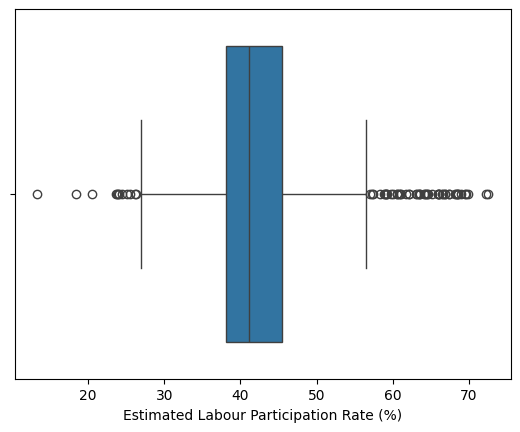

In [ ]:
# outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Estimated Labour Participation Rate (%)'])
plt.show()
# there are outliers in estimated unemployemnt rate,Estimated Employed,Estimated Labour Participation Rate (%)
# i decide to keep the outliers

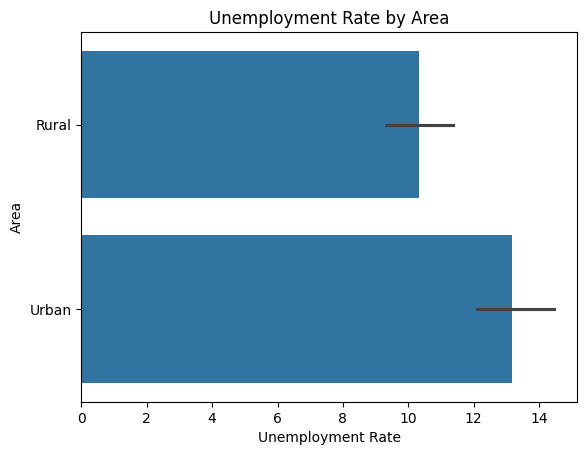

In [ ]:
# visulaization
# barchart
#
sns.barplot(x=df['Estimated Unemployment Rate (%)'],y=df['Area'])
plt.title('Unemployment Rate by Area')
plt.xlabel('Unemployment Rate')
plt.show()

unemployement in urban is more than in rural

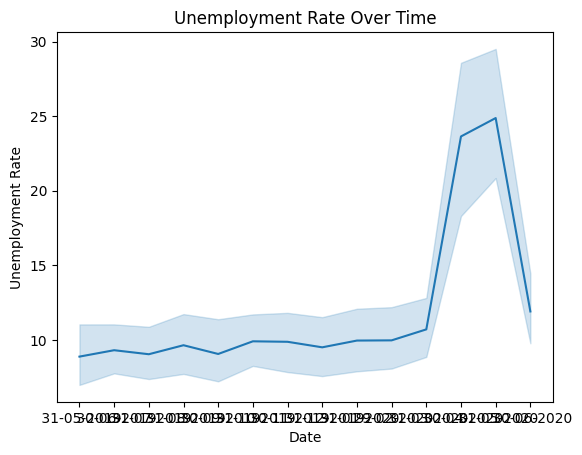

In [ ]:
sns.lineplot(x=df['Date'],y=df['Estimated Unemployment Rate (%)'])
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.show()

unemployement rate increase after '2020-05'

/tmp/ipython-input-1389967824.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="viridis")


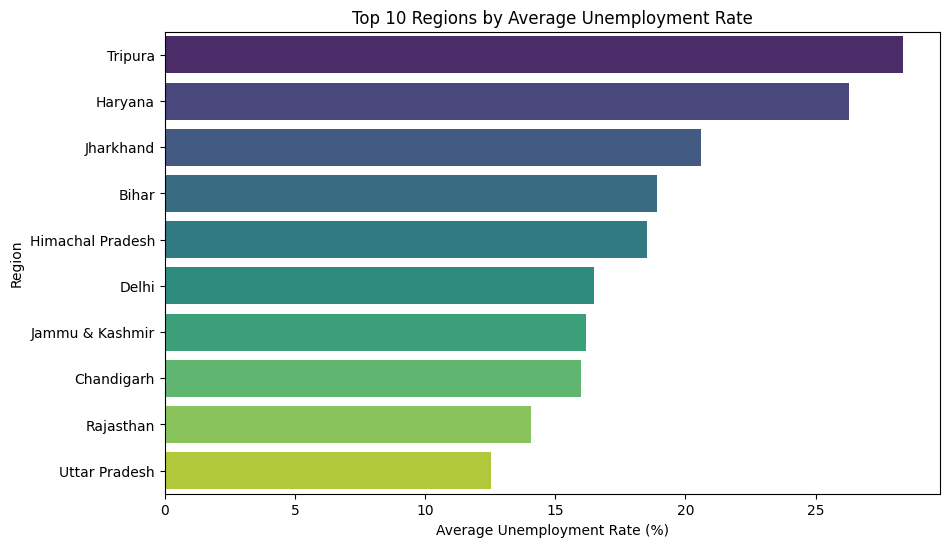

In [ ]:
top10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()

Text(0, 0.5, 'Labour Participation Rate')

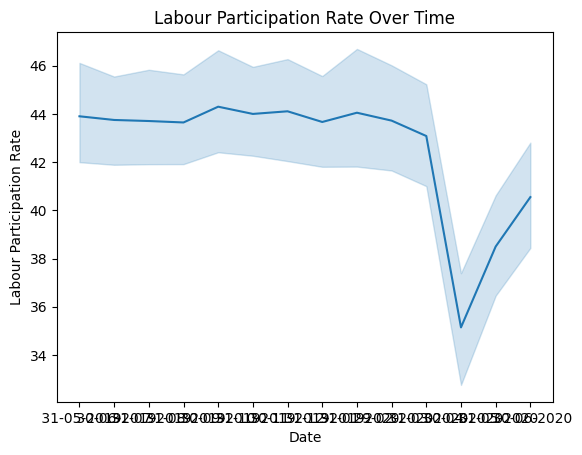

In [ ]:
sns.lineplot(x=df['Date'],y=df['Estimated Labour Participation Rate (%)'])
plt.title('Labour Participation Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Labour Participation Rate')


/tmp/ipython-input-2815847879.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=df['Estimated Labour Participation Rate (%)'],y=df['Estimated Employed'],palette='"viridis"')


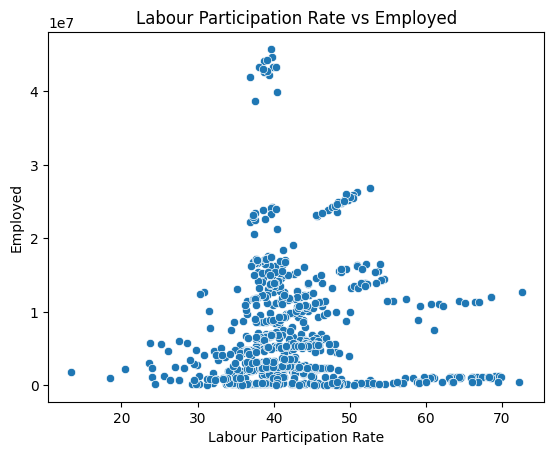

In [ ]:
sns.scatterplot(x=df['Estimated Labour Participation Rate (%)'],y=df['Estimated Employed'],palette='"viridis"')
plt.title('Labour Participation Rate vs Employed')
plt.xlabel('Labour Participation Rate')
plt.ylabel('Employed')
plt.show()

this is no relation between them



In [ ]:
df['Estimated Unemployment Rate (%)'].corr(df['Estimated Employed'])


np.float64(-0.2228763995221478)